In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";", encoding="utf-8-sig", decimal=",")
t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})

t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";", encoding="utf-8-sig", decimal=",")
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})

t2012.head()

,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2


In [4]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [5]:
raw = pd.read_excel("Tabela_1_1_1.xls", sheet_name="2022", header=None)
raw = raw.iloc[8:41].reset_index(drop=True)
raw.columns = [
    "Estado",
    "Total_horas",
    "Total_Branca",
    "Total_PretaParda",
    "Homem_Branca",
    "Homem_PretaParda",
    "Mulher_Branca",
    "Mulher_PretaParda",
]
for coluna in raw.columns[1:]:
    raw[coluna] = pd.to_numeric(raw[coluna])

estados = comp["Estado"].tolist()
cuidados = raw[raw["Estado"].isin(estados)].reset_index(drop=True)
cuidados["Homens_horas"] = cuidados[["Homem_Branca", "Homem_PretaParda"]].mean(axis=1)
cuidados["Mulheres_horas"] = cuidados[["Mulher_Branca", "Mulher_PretaParda"]].mean(axis=1)
cuidados = cuidados[["Estado", "Total_horas", "Homens_horas", "Mulheres_horas"]]
cuidados

,Estado,Total_horas,Homens_horas,Mulheres_horas
0,Rondônia,17.014162,12.327604,20.737149
1,Acre,13.606903,10.241551,16.420553
2,Amazonas,16.807290,12.527813,19.740977
3,Roraima,13.639257,10.645702,16.348061
4,Pará,16.474268,11.275506,20.713127
5,Amapá,13.586656,10.933133,16.278533
6,Tocantins,15.815781,11.208240,19.646556
7,Maranhão,16.669614,11.551266,20.310323
8,Piauí,17.960366,11.731569,22.094752
9,Ceará,19.499293,12.504129,23.985996


In [6]:
final = comp.merge(cuidados, on="Estado", how="inner")
final

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,Total_horas,Homens_horas,Mulheres_horas
0,AC,12,Acre,45.3,54.7,53.2,46.8,13.606903,10.241551,16.420553
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129,12.739500,24.975146
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,16.807290,12.527813,19.740977
3,AP,16,Amapá,48.1,51.9,51.1,48.9,13.586656,10.933133,16.278533
4,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776,10.767240,22.894924
5,CE,23,Ceará,51.1,48.9,52.7,47.3,19.499293,12.504129,23.985996
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,15.096351,10.929615,18.522728
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,17.111106,11.908080,21.330544
8,GO,52,Goiás,41.0,59.0,47.5,52.5,15.186471,10.584154,19.014378
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,16.669614,11.551266,20.310323


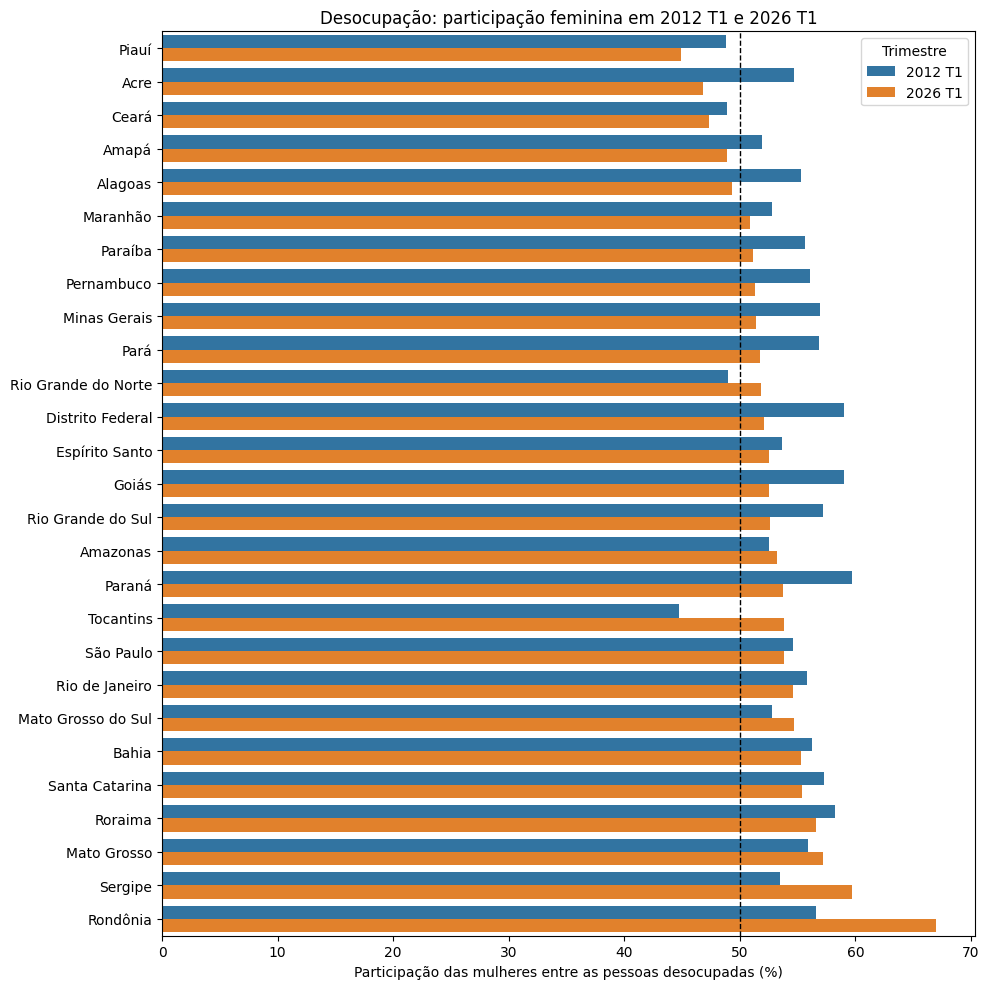

In [7]:
ordem = comp.sort_values("mulheres_2026")["Estado"]
longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Trimestre")
fig.tight_layout()
plt.show()

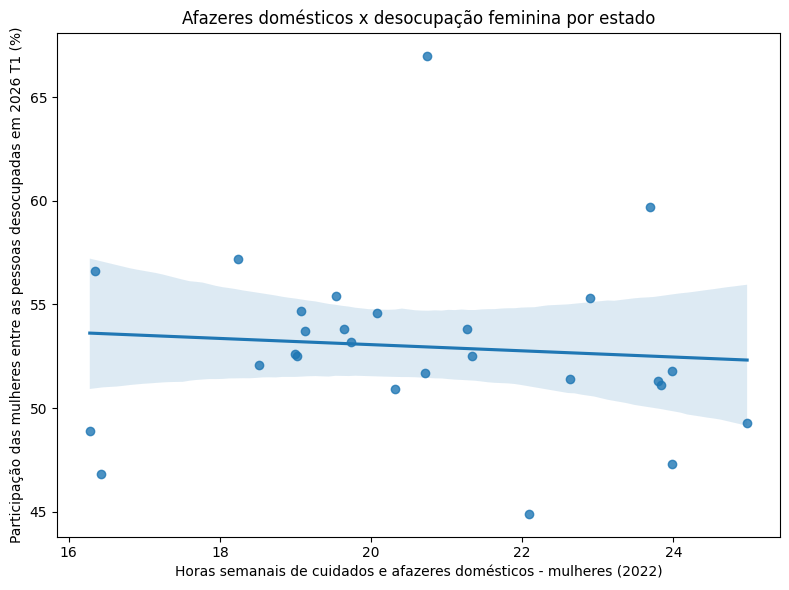

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=final, x="Mulheres_horas", y="mulheres_2026", ax=ax)
ax.set_xlabel("Horas semanais de cuidados e afazeres domésticos - mulheres (2022)")
ax.set_ylabel("Participação das mulheres entre as pessoas desocupadas em 2026 T1 (%)")
ax.set_title("Afazeres domésticos x desocupação feminina por estado")
fig.tight_layout()
plt.show()